In [ ]:
# =============================================================================
# LGD PREDICTION ANALYSIS - y_true vs y_pred_raw
# =============================================================================
# 
# This notebook section analyzes LGD predictions by:
# 1. Loading results from pickle files in results/{experiment}/lgd/
# 2. Comparing y_true vs y_pred_raw (raw predictions before clipping)
# 3. Clipping y_pred_raw to [min(y_true), max(y_true)] instead of [0, 1]
# 4. Calculating metrics for both clipping approaches
# =============================================================================

# -----------------------------------------------------------------------------
# IMPORTS
# -----------------------------------------------------------------------------
import pickle
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    median_absolute_error, max_error, explained_variance_score
)

# -----------------------------------------------------------------------------
# CONFIGURATION
# -----------------------------------------------------------------------------

# Project root (notebook is in notebooks/ folder, so go up one level)
PROJECT_ROOT = Path(".").resolve().parent
EXPERIMENT = "experiment1"

# Paths
RESULTS_DIR = PROJECT_ROOT / "results" / EXPERIMENT
LGD_RESULTS_DIR = RESULTS_DIR / "lgd"

print(f"=" * 80)
print("LGD PREDICTION ANALYSIS SETUP")
print(f"=" * 80)
print(f"Project root:     {PROJECT_ROOT}")
print(f"Results dir:      {RESULTS_DIR}")
print(f"LGD results dir:  {LGD_RESULTS_DIR}")
print(f"LGD dir exists:   {LGD_RESULTS_DIR.exists()}")

if LGD_RESULTS_DIR.exists():
    pkl_files = list(LGD_RESULTS_DIR.glob("*.pkl"))
    print(f"LGD pickle files: {len(pkl_files)}")
    for f in pkl_files[:10]:  # Show first 10
        print(f"  - {f.name}")
    if len(pkl_files) > 10:
        print(f"  ... and {len(pkl_files) - 10} more")

# -----------------------------------------------------------------------------
# ALGORITHM DISPLAY NAMES
# -----------------------------------------------------------------------------

ALGORITHM_DISPLAY_NAMES = {
    'tabpfn': 'TabPFN',
    'tabpfn_v2': 'TabPFN-v2',
    'tabpfnv2': 'TabPFN-v2',
    'xgboost': 'XGBoost',
    'lightgbm': 'LightGBM',
    'catboost': 'CatBoost',
    'randomforest': 'RForest',
    'RandomForest': 'RForest',
    'logreg': 'LogReg',
    'LogReg': 'LogReg',
    'linearregression': 'LinReg',
    'LinearRegression': 'LinReg',
    'knn': 'KNN',
    'svm': 'SVM',
    'naivebayes': 'NaiveBayes',
    'NaiveBayes': 'NaiveBayes',
    'ncm': 'NCM',
    'NCM': 'NCM',
    'dummy': 'Dummy',
    'tabnet': 'TabNet',
    'mlp': 'MLP',
    'resnet': 'ResNet',
    'saint': 'SAINT',
    'fttransformer': 'FT-Trans',
    'ftt': 'FT-Trans',
    'node': 'NODE',
}

def get_display_name(algorithm_name):
    """Convert algorithm name to display name."""
    return ALGORITHM_DISPLAY_NAMES.get(algorithm_name, algorithm_name)


# -----------------------------------------------------------------------------
# RESULT LOADING FUNCTIONS
# -----------------------------------------------------------------------------

def load_lgd_dataset_results(results_dir: Path, dataset: str) -> dict:
    """
    Load LGD results for a specific dataset from pickle file.
    
    Args:
        results_dir: Path to lgd results directory
        dataset: Dataset name (without .pkl extension)
        
    Returns:
        Dictionary with structure:
        {method_name: {fold_id: {y_true, y_pred_raw, y_pred, metrics, ...}}}
    """
    # Try different possible filenames
    possible_paths = [
        results_dir / f"{dataset}.pkl",
        results_dir / f"{dataset.lower()}.pkl",
        results_dir / f"{dataset.upper()}.pkl",
    ]
    
    pkl_path = None
    for path in possible_paths:
        if path.exists():
            pkl_path = path
            break
    
    if pkl_path is None:
        raise FileNotFoundError(f"No pickle file found for dataset '{dataset}' in {results_dir}")
    
    print(f"Loading: {pkl_path}")
    
    with open(pkl_path, 'rb') as f:
        results = pickle.load(f)
    
    return results


def list_lgd_datasets(results_dir: Path) -> list:
    """List all available LGD datasets."""
    if not results_dir.exists():
        return []
    
    datasets = []
    for pkl_file in results_dir.glob("*.pkl"):
        # Skip metadata files
        if "_metadata" not in pkl_file.stem:
            datasets.append(pkl_file.stem)
    
    return sorted(datasets)


# -----------------------------------------------------------------------------
# METRIC CALCULATION FUNCTIONS
# -----------------------------------------------------------------------------

def calculate_lgd_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """
    Calculate comprehensive regression metrics for LGD.
    
    Args:
        y_true: Ground truth LGD values
        y_pred: Predicted LGD values
        
    Returns:
        Dictionary of metric names to values
    """
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    
    metrics = {}
    
    # R² (can be negative if worse than mean prediction)
    try:
        metrics['R2'] = float(r2_score(y_true, y_pred))
    except Exception:
        metrics['R2'] = np.nan
    
    # MSE and RMSE
    metrics['MSE'] = float(mean_squared_error(y_true, y_pred))
    metrics['RMSE'] = float(np.sqrt(metrics['MSE']))
    
    # MAE
    metrics['MAE'] = float(mean_absolute_error(y_true, y_pred))
    
    # Median Absolute Error (robust to outliers)
    metrics['MedAE'] = float(median_absolute_error(y_true, y_pred))
    
    # Max Error
    metrics['MaxError'] = float(max_error(y_true, y_pred))
    
    # Explained Variance
    metrics['Explained_Variance'] = float(explained_variance_score(y_true, y_pred))
    
    # MAPE (exclude zeros)
    mask = y_true != 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
        metrics['MAPE'] = float(mape)
    else:
        metrics['MAPE'] = np.nan
    
    # Pearson Correlation
    if np.std(y_pred) > 1e-10 and np.std(y_true) > 1e-10:
        metrics['Pearson_Corr'] = float(np.corrcoef(y_true, y_pred)[0, 1])
    else:
        metrics['Pearson_Corr'] = np.nan
    
    # Spearman Correlation
    try:
        spearman_corr, _ = scipy_stats.spearmanr(y_true, y_pred)
        metrics['Spearman_Corr'] = float(spearman_corr)
    except Exception:
        metrics['Spearman_Corr'] = np.nan
    
    return metrics


def clip_to_target_range(y_true: np.ndarray, y_pred_raw: np.ndarray) -> tuple:
    """
    Clip predictions to [min(y_true), max(y_true)] instead of [0, 1].
    
    Args:
        y_true: Ground truth values
        y_pred_raw: Raw predictions (before any clipping)
        
    Returns:
        Tuple of (clipped_predictions, n_below, n_above, clip_min, clip_max)
    """
    y_true = np.asarray(y_true).ravel()
    y_pred_raw = np.asarray(y_pred_raw).ravel()
    
    clip_min = float(y_true.min())
    clip_max = float(y_true.max())
    
    n_below = int(np.sum(y_pred_raw < clip_min))
    n_above = int(np.sum(y_pred_raw > clip_max))
    
    y_pred_clipped = np.clip(y_pred_raw, clip_min, clip_max)
    
    return y_pred_clipped, n_below, n_above, clip_min, clip_max


# -----------------------------------------------------------------------------
# MAIN ANALYSIS FUNCTION
# -----------------------------------------------------------------------------

def analyze_lgd_predictions(
    results_dir: Path,
    dataset: str,
    method: str = None,
    figsize=(16, 20),
    save_path=None
):
    """
    Comprehensive analysis of LGD predictions: y_true vs y_pred_raw.
    
    Clips predictions to [min(y_true), max(y_true)] instead of [0, 1].
    
    Args:
        results_dir: Path to lgd results directory
        dataset: Dataset name
        method: Specific method to analyze (None = use best by R2)
        figsize: Figure size
        save_path: Optional path to save figure
        
    Returns:
        Dictionary with analysis results
    """
    print("=" * 80)
    print("LGD PREDICTION ANALYSIS: y_true vs y_pred_raw")
    print("=" * 80)
    
    # Load results
    try:
        dataset_results = load_lgd_dataset_results(results_dir, dataset)
    except FileNotFoundError as e:
        print(f"❌ {e}")
        return None
    
    # Get available methods
    methods = list(dataset_results.keys())
    print(f"\nDataset: {dataset}")
    print(f"Available methods: {methods}")
    
    # Select method (use best by R2 if not specified)
    if method is None:
        # Find best method by average R2
        method_r2 = {}
        for m in methods:
            r2_values = []
            for fold_id, fold_data in dataset_results[m].items():
                if 'metrics' in fold_data and 'R2' in fold_data['metrics']:
                    r2_values.append(fold_data['metrics']['R2'])
            if r2_values:
                method_r2[m] = np.mean(r2_values)
        
        if method_r2:
            method = max(method_r2, key=method_r2.get)
            print(f"Selected method (best R2): {method} (R2={method_r2[method]:.4f})")
        else:
            method = methods[0]
            print(f"Selected method (first): {method}")
    
    if method not in dataset_results:
        print(f"❌ Method '{method}' not found. Available: {methods}")
        return None
    
    method_results = dataset_results[method]
    fold_ids = sorted(method_results.keys())
    print(f"Folds: {fold_ids}")
    
    # Collect all predictions across folds
    all_y_true = []
    all_y_pred_raw = []
    all_y_pred_01 = []  # Clipped to [0, 1] (original)
    fold_metrics_01 = []
    fold_metrics_target = []
    
    for fold_id in fold_ids:
        fold_data = method_results[fold_id]
        
        # Extract arrays
        y_true = np.asarray(fold_data['y_true']).ravel()
        
        # Get raw predictions (before clipping)
        if 'y_pred_raw' in fold_data:
            y_pred_raw = np.asarray(fold_data['y_pred_raw']).ravel()
        elif 'y_pred' in fold_data:
            # Fallback: use y_pred (already clipped to [0,1])
            y_pred_raw = np.asarray(fold_data['y_pred']).ravel()
            print(f"  ⚠️ Fold {fold_id}: Using y_pred (y_pred_raw not available)")
        else:
            print(f"  ❌ Fold {fold_id}: No predictions found")
            continue
        
        all_y_true.extend(y_true)
        all_y_pred_raw.extend(y_pred_raw)
        
        # Clip to [0, 1] (original approach)
        y_pred_01 = np.clip(y_pred_raw, 0.0, 1.0)
        all_y_pred_01.extend(y_pred_01)
        
        # Calculate metrics for [0, 1] clipping
        metrics_01 = calculate_lgd_metrics(y_true, y_pred_01)
        metrics_01['fold'] = fold_id
        fold_metrics_01.append(metrics_01)
        
        # Clip to [min(y_true), max(y_true)] (new approach)
        y_pred_target, n_below, n_above, clip_min, clip_max = clip_to_target_range(y_true, y_pred_raw)
        
        # Calculate metrics for target range clipping
        metrics_target = calculate_lgd_metrics(y_true, y_pred_target)
        metrics_target['fold'] = fold_id
        metrics_target['clip_min'] = clip_min
        metrics_target['clip_max'] = clip_max
        metrics_target['n_below'] = n_below
        metrics_target['n_above'] = n_above
        fold_metrics_target.append(metrics_target)
    
    # Convert to numpy arrays
    all_y_true = np.array(all_y_true)
    all_y_pred_raw = np.array(all_y_pred_raw)
    all_y_pred_01 = np.array(all_y_pred_01)
    
    # Global clipping to target range
    y_min_global = all_y_true.min()
    y_max_global = all_y_true.max()
    all_y_pred_target = np.clip(all_y_pred_raw, y_min_global, y_max_global)
    
    # Calculate overall metrics
    overall_metrics_01 = calculate_lgd_metrics(all_y_true, all_y_pred_01)
    overall_metrics_target = calculate_lgd_metrics(all_y_true, all_y_pred_target)
    
    # Count out-of-range predictions
    n_below_0 = int(np.sum(all_y_pred_raw < 0))
    n_above_1 = int(np.sum(all_y_pred_raw > 1))
    n_below_target = int(np.sum(all_y_pred_raw < y_min_global))
    n_above_target = int(np.sum(all_y_pred_raw > y_max_global))
    n_total = len(all_y_pred_raw)
    
    # =========================================================================
    # PRINT SUMMARY
    # =========================================================================
    
    print(f"\n📋 ANALYSIS INFO:")
    print("-" * 60)
    print(f"   Dataset:         {dataset}")
    print(f"   Method:          {method} ({get_display_name(method)})")
    print(f"   Total Samples:   {n_total:,}")
    print(f"   Number of Folds: {len(fold_ids)}")
    
    print(f"\n📊 TARGET (y_true) STATISTICS:")
    print("-" * 60)
    print(f"   Min:    {all_y_true.min():.6f}")
    print(f"   Max:    {all_y_true.max():.6f}")
    print(f"   Mean:   {all_y_true.mean():.6f}")
    print(f"   Std:    {all_y_true.std():.6f}")
    print(f"   Median: {np.median(all_y_true):.6f}")
    
    print(f"\n📊 RAW PREDICTIONS (y_pred_raw) STATISTICS:")
    print("-" * 60)
    print(f"   Min:    {all_y_pred_raw.min():.6f}")
    print(f"   Max:    {all_y_pred_raw.max():.6f}")
    print(f"   Mean:   {all_y_pred_raw.mean():.6f}")
    print(f"   Std:    {all_y_pred_raw.std():.6f}")
    print(f"   Median: {np.median(all_y_pred_raw):.6f}")
    
    print(f"\n⚠️ OUT-OF-RANGE PREDICTIONS:")
    print("-" * 60)
    print(f"   [0, 1] clipping:")
    print(f"      Below 0: {n_below_0:,} ({100*n_below_0/n_total:.2f}%)")
    print(f"      Above 1: {n_above_1:,} ({100*n_above_1/n_total:.2f}%)")
    print(f"      Total:   {n_below_0 + n_above_1:,} ({100*(n_below_0+n_above_1)/n_total:.2f}%)")
    print(f"\n   [{y_min_global:.4f}, {y_max_global:.4f}] clipping (target range):")
    print(f"      Below min: {n_below_target:,} ({100*n_below_target/n_total:.2f}%)")
    print(f"      Above max: {n_above_target:,} ({100*n_above_target/n_total:.2f}%)")
    print(f"      Total:     {n_below_target + n_above_target:,} ({100*(n_below_target+n_above_target)/n_total:.2f}%)")
    
    print(f"\n📈 METRICS COMPARISON:")
    print("-" * 80)
    print(f"{'Metric':<20} {'[0, 1]':>15} {'[{:.4f}, {:.4f}]':>20} {'Improvement':>15}".format(y_min_global, y_max_global))
    print("-" * 80)
    
    for metric in ['R2', 'RMSE', 'MAE', 'MedAE', 'Pearson_Corr', 'Spearman_Corr']:
        val_01 = overall_metrics_01[metric]
        val_target = overall_metrics_target[metric]
        
        # Calculate improvement (positive = target range is better)
        if metric in ['RMSE', 'MAE', 'MedAE', 'MaxError', 'MSE', 'MAPE']:
            improvement = val_01 - val_target  # Lower is better
        else:
            improvement = val_target - val_01  # Higher is better
        
        print(f"{metric:<20} {val_01:>15.6f} {val_target:>20.6f} {improvement:>+15.6f}")
    
    # =========================================================================
    # VISUALIZATION
    # =========================================================================
    
    fig, axes = plt.subplots(4, 2, figsize=figsize)
    
    # 1. Distribution: y_true vs y_pred_raw
    ax1 = axes[0, 0]
    ax1.hist(all_y_true, bins=50, alpha=0.6, label='y_true', color='steelblue', edgecolor='black')
    ax1.hist(all_y_pred_raw, bins=50, alpha=0.6, label='y_pred_raw', color='coral', edgecolor='black')
    ax1.axvline(all_y_true.mean(), color='blue', linestyle='--', linewidth=2, 
                label=f'y_true mean: {all_y_true.mean():.4f}')
    ax1.axvline(all_y_pred_raw.mean(), color='red', linestyle='--', linewidth=2, 
                label=f'y_pred mean: {all_y_pred_raw.mean():.4f}')
    ax1.set_xlabel('LGD Value', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax1.set_title('Distribution: y_true vs y_pred_raw', fontsize=12, fontweight='bold')
    ax1.legend(loc='upper right', fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    # 2. Distribution: Comparison of clipping approaches
    ax2 = axes[0, 1]
    ax2.hist(all_y_pred_01, bins=50, alpha=0.6, label='Clipped [0, 1]', color='coral', edgecolor='black')
    ax2.hist(all_y_pred_target, bins=50, alpha=0.6, label=f'Clipped [{y_min_global:.3f}, {y_max_global:.3f}]', 
             color='green', edgecolor='black')
    ax2.axvline(0, color='red', linestyle=':', linewidth=2, alpha=0.5)
    ax2.axvline(1, color='red', linestyle=':', linewidth=2, alpha=0.5, label='[0, 1] bounds')
    ax2.axvline(y_min_global, color='green', linestyle=':', linewidth=2, alpha=0.7)
    ax2.axvline(y_max_global, color='green', linestyle=':', linewidth=2, alpha=0.7, label='Target bounds')
    ax2.set_xlabel('LGD Value', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax2.set_title('Clipping Comparison: [0,1] vs Target Range', fontsize=12, fontweight='bold')
    ax2.legend(loc='upper right', fontsize=9)
    ax2.grid(True, alpha=0.3)
    
    # 3. Scatter: Predicted vs Actual (Clipped to [0, 1])
    ax3 = axes[1, 0]
    ax3.scatter(all_y_true, all_y_pred_01, alpha=0.3, s=20, c='coral', edgecolors='none')
    min_val = min(all_y_true.min(), all_y_pred_01.min())
    max_val = max(all_y_true.max(), all_y_pred_01.max())
    ax3.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Perfect Prediction')
    z = np.polyfit(all_y_true, all_y_pred_01, 1)
    p = np.poly1d(z)
    ax3.plot(all_y_true, p(all_y_true), 'b-', linewidth=2, alpha=0.7, 
             label=f'Fit: y={z[0]:.3f}x+{z[1]:.3f}')
    ax3.set_xlabel('Actual (y_true)', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Predicted (clipped [0,1])', fontsize=11, fontweight='bold')
    ax3.set_title(f'Scatter: Clipped to [0, 1]\nR² = {overall_metrics_01["R2"]:.4f}', 
                  fontsize=12, fontweight='bold')
    ax3.legend(loc='upper left', fontsize=9)
    ax3.grid(True, alpha=0.3)
    
    # 4. Scatter: Predicted vs Actual (Clipped to Target Range)
    ax4 = axes[1, 1]
    ax4.scatter(all_y_true, all_y_pred_target, alpha=0.3, s=20, c='green', edgecolors='none')
    ax4.plot([y_min_global, y_max_global], [y_min_global, y_max_global], 'k--', linewidth=2, 
             label='Perfect Prediction')
    z = np.polyfit(all_y_true, all_y_pred_target, 1)
    p = np.poly1d(z)
    ax4.plot(all_y_true, p(all_y_true), 'b-', linewidth=2, alpha=0.7,
             label=f'Fit: y={z[0]:.3f}x+{z[1]:.3f}')
    ax4.set_xlabel('Actual (y_true)', fontsize=11, fontweight='bold')
    ax4.set_ylabel(f'Predicted (clipped [{y_min_global:.3f}, {y_max_global:.3f}])', fontsize=11, fontweight='bold')
    ax4.set_title(f'Scatter: Clipped to Target Range\nR² = {overall_metrics_target["R2"]:.4f}', 
                  fontsize=12, fontweight='bold')
    ax4.legend(loc='upper left', fontsize=9)
    ax4.grid(True, alpha=0.3)
    
    # 5. Residual Distribution (Clipped to [0, 1])
    ax5 = axes[2, 0]
    residuals_01 = all_y_pred_01 - all_y_true
    ax5.hist(residuals_01, bins=50, alpha=0.7, color='coral', edgecolor='black')
    ax5.axvline(0, color='black', linestyle='--', linewidth=2)
    ax5.axvline(residuals_01.mean(), color='red', linestyle='-', linewidth=2, 
                label=f'Mean: {residuals_01.mean():.4f}')
    ax5.set_xlabel('Residual (y_pred - y_true)', fontsize=11, fontweight='bold')
    ax5.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax5.set_title(f'Residual Distribution [0, 1]\nStd: {residuals_01.std():.4f}', fontsize=12, fontweight='bold')
    ax5.legend(loc='upper right', fontsize=9)
    ax5.grid(True, alpha=0.3)
    
    # 6. Residual Distribution (Clipped to Target Range)
    ax6 = axes[2, 1]
    residuals_target = all_y_pred_target - all_y_true
    ax6.hist(residuals_target, bins=50, alpha=0.7, color='green', edgecolor='black')
    ax6.axvline(0, color='black', linestyle='--', linewidth=2)
    ax6.axvline(residuals_target.mean(), color='red', linestyle='-', linewidth=2,
                label=f'Mean: {residuals_target.mean():.4f}')
    ax6.set_xlabel('Residual (y_pred - y_true)', fontsize=11, fontweight='bold')
    ax6.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax6.set_title(f'Residual Distribution [Target Range]\nStd: {residuals_target.std():.4f}', 
                  fontsize=12, fontweight='bold')
    ax6.legend(loc='upper right', fontsize=9)
    ax6.grid(True, alpha=0.3)
    
    # 7. Residuals vs Actual (heteroscedasticity check)
    ax7 = axes[3, 0]
    ax7.scatter(all_y_true, residuals_target, alpha=0.3, s=20, c='green', edgecolors='none')
    ax7.axhline(0, color='black', linestyle='--', linewidth=2)
    ax7.set_xlabel('Actual (y_true)', fontsize=11, fontweight='bold')
    ax7.set_ylabel('Residual', fontsize=11, fontweight='bold')
    ax7.set_title('Residuals vs Actual\n(Check for heteroscedasticity)', fontsize=12, fontweight='bold')
    ax7.grid(True, alpha=0.3)
    
    # 8. Per-Fold R² Comparison
    ax8 = axes[3, 1]
    fold_names = [m['fold'] for m in fold_metrics_01]
    r2_01 = [m['R2'] for m in fold_metrics_01]
    r2_target = [m['R2'] for m in fold_metrics_target]
    
    x = np.arange(len(fold_names))
    width = 0.35
    
    bars1 = ax8.bar(x - width/2, r2_01, width, label='[0, 1]', color='coral', edgecolor='black')
    bars2 = ax8.bar(x + width/2, r2_target, width, label='Target Range', color='green', edgecolor='black')
    
    ax8.set_xlabel('Fold', fontsize=11, fontweight='bold')
    ax8.set_ylabel('R²', fontsize=11, fontweight='bold')
    ax8.set_title('Per-Fold R² Comparison', fontsize=12, fontweight='bold')
    ax8.set_xticks(x)
    ax8.set_xticklabels([str(f) for f in fold_names], rotation=45, ha='right')
    ax8.legend(loc='lower right')
    ax8.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar, val in zip(bars1, r2_01):
        ax8.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    for bar, val in zip(bars2, r2_target):
        ax8.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    
    plt.suptitle(f'LGD Prediction Analysis: {dataset} - {get_display_name(method)}\n'
                 f'Comparing [0, 1] vs [{y_min_global:.4f}, {y_max_global:.4f}] clipping',
                 fontsize=14, fontweight='bold', y=1.01)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\n📁 Figure saved: {save_path}")
    
    plt.show()
    
    # Return analysis results
    return {
        'dataset': dataset,
        'method': method,
        'y_true': all_y_true,
        'y_pred_raw': all_y_pred_raw,
        'y_pred_01': all_y_pred_01,
        'y_pred_target': all_y_pred_target,
        'target_range': (y_min_global, y_max_global),
        'metrics_01': overall_metrics_01,
        'metrics_target': overall_metrics_target,
        'fold_metrics_01': pd.DataFrame(fold_metrics_01),
        'fold_metrics_target': pd.DataFrame(fold_metrics_target),
        'clipping_stats': {
            '01_below': n_below_0,
            '01_above': n_above_1,
            'target_below': n_below_target,
            'target_above': n_above_target,
        }
    }


# -----------------------------------------------------------------------------
# COMPARE ALL METHODS FOR A DATASET
# -----------------------------------------------------------------------------

def compare_all_methods_clipping(
    results_dir: Path,
    dataset: str,
    figsize=(16, 10),
    save_path=None
):
    """
    Compare clipping impact across all methods for an LGD dataset.
    
    Args:
        results_dir: Path to lgd results directory
        dataset: Dataset name
        figsize: Figure size
        save_path: Optional path to save figure
        
    Returns:
        DataFrame with comparison results
    """
    print("=" * 80)
    print("LGD CLIPPING IMPACT: ALL METHODS COMPARISON")
    print("=" * 80)
    
    # Load results
    try:
        dataset_results = load_lgd_dataset_results(results_dir, dataset)
    except FileNotFoundError as e:
        print(f"❌ {e}")
        return None
    
    methods = list(dataset_results.keys())
    print(f"\nDataset: {dataset}")
    print(f"Methods: {len(methods)}")
    
    comparison_data = []
    
    for method in methods:
        method_results = dataset_results[method]
        
        all_y_true = []
        all_y_pred_raw = []
        
        for fold_id, fold_data in method_results.items():
            y_true = np.asarray(fold_data['y_true']).ravel()
            
            if 'y_pred_raw' in fold_data:
                y_pred_raw = np.asarray(fold_data['y_pred_raw']).ravel()
            elif 'y_pred' in fold_data:
                y_pred_raw = np.asarray(fold_data['y_pred']).ravel()
            else:
                continue
            
            all_y_true.extend(y_true)
            all_y_pred_raw.extend(y_pred_raw)
        
        if not all_y_true:
            continue
        
        all_y_true = np.array(all_y_true)
        all_y_pred_raw = np.array(all_y_pred_raw)
        
        # Calculate metrics for both clipping approaches
        y_pred_01 = np.clip(all_y_pred_raw, 0.0, 1.0)
        
        y_min = all_y_true.min()
        y_max = all_y_true.max()
        y_pred_target = np.clip(all_y_pred_raw, y_min, y_max)
        
        metrics_01 = calculate_lgd_metrics(all_y_true, y_pred_01)
        metrics_target = calculate_lgd_metrics(all_y_true, y_pred_target)
        
        comparison_data.append({
            'method': method,
            'display_name': get_display_name(method),
            'n_samples': len(all_y_true),
            'target_min': y_min,
            'target_max': y_max,
            'n_below_0': int(np.sum(all_y_pred_raw < 0)),
            'n_above_1': int(np.sum(all_y_pred_raw > 1)),
            'n_below_target': int(np.sum(all_y_pred_raw < y_min)),
            'n_above_target': int(np.sum(all_y_pred_raw > y_max)),
            'R2_01': metrics_01['R2'],
            'R2_target': metrics_target['R2'],
            'R2_improvement': metrics_target['R2'] - metrics_01['R2'],
            'RMSE_01': metrics_01['RMSE'],
            'RMSE_target': metrics_target['RMSE'],
            'RMSE_improvement': metrics_01['RMSE'] - metrics_target['RMSE'],  # Lower is better
            'MAE_01': metrics_01['MAE'],
            'MAE_target': metrics_target['MAE'],
            'MAE_improvement': metrics_01['MAE'] - metrics_target['MAE'],  # Lower is better
        })
    
    if not comparison_data:
        print("❌ No valid results found")
        return None
    
    comparison_df = pd.DataFrame(comparison_data)
    comparison_df = comparison_df.sort_values('R2_target', ascending=False)
    
    # Print summary table
    print(f"\n📊 CLIPPING IMPACT SUMMARY:")
    print("-" * 100)
    print(f"{'Method':<20} {'R²[0,1]':>12} {'R²[target]':>12} {'Δ R²':>10} {'RMSE[0,1]':>12} {'RMSE[target]':>12} {'Δ RMSE':>10}")
    print("-" * 100)
    
    for _, row in comparison_df.iterrows():
        print(f"{row['display_name']:<20} {row['R2_01']:>12.4f} {row['R2_target']:>12.4f} "
              f"{row['R2_improvement']:>+10.4f} {row['RMSE_01']:>12.4f} {row['RMSE_target']:>12.4f} "
              f"{row['RMSE_improvement']:>+10.4f}")
    
    # =========================================================================
    # VISUALIZATION
    # =========================================================================
    
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    
    methods_display = comparison_df['display_name'].tolist()
    x = np.arange(len(methods_display))
    width = 0.35
    
    # 1. R² Comparison
    ax1 = axes[0, 0]
    bars1 = ax1.bar(x - width/2, comparison_df['R2_01'], width, label='[0, 1]', color='coral', edgecolor='black')
    bars2 = ax1.bar(x + width/2, comparison_df['R2_target'], width, label='Target Range', color='green', edgecolor='black')
    ax1.set_ylabel('R²', fontsize=11, fontweight='bold')
    ax1.set_title('R² Comparison: [0,1] vs Target Range', fontsize=12, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(methods_display, rotation=45, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    # 2. RMSE Comparison
    ax2 = axes[0, 1]
    bars3 = ax2.bar(x - width/2, comparison_df['RMSE_01'], width, label='[0, 1]', color='coral', edgecolor='black')
    bars4 = ax2.bar(x + width/2, comparison_df['RMSE_target'], width, label='Target Range', color='green', edgecolor='black')
    ax2.set_ylabel('RMSE', fontsize=11, fontweight='bold')
    ax2.set_title('RMSE Comparison: [0,1] vs Target Range', fontsize=12, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(methods_display, rotation=45, ha='right')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    # 3. R² Improvement
    ax3 = axes[1, 0]
    colors = ['green' if v > 0 else 'red' for v in comparison_df['R2_improvement']]
    ax3.bar(x, comparison_df['R2_improvement'], color=colors, edgecolor='black')
    ax3.axhline(0, color='black', linestyle='-', linewidth=1)
    ax3.set_ylabel('Δ R² (Target - [0,1])', fontsize=11, fontweight='bold')
    ax3.set_title('R² Improvement from Target Range Clipping\n(Positive = Target Range is Better)', fontsize=12, fontweight='bold')
    ax3.set_xticks(x)
    ax3.set_xticklabels(methods_display, rotation=45, ha='right')
    ax3.grid(True, alpha=0.3, axis='y')
    
    # 4. Out-of-Range Predictions
    ax4 = axes[1, 1]
    n_below = comparison_df['n_below_0'].values
    n_above = comparison_df['n_above_1'].values
    ax4.bar(x, n_below, label='Below 0', color='orange', edgecolor='black')
    ax4.bar(x, n_above, bottom=n_below, label='Above 1', color='purple', edgecolor='black')
    ax4.set_ylabel('Count', fontsize=11, fontweight='bold')
    ax4.set_title('Out-of-Range Predictions (vs [0,1])', fontsize=12, fontweight='bold')
    ax4.set_xticks(x)
    ax4.set_xticklabels(methods_display, rotation=45, ha='right')
    ax4.legend()
    ax4.grid(True, alpha=0.3, axis='y')
    
    plt.suptitle(f'LGD Clipping Impact Analysis: {dataset}', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    return comparison_df


print("\n✅ LGD Analysis functions loaded successfully!")
print("\nAvailable functions:")
print("  - analyze_lgd_predictions(results_dir, dataset, method=None)")
print("  - compare_all_methods_clipping(results_dir, dataset)")
print("  - list_lgd_datasets(results_dir)")

In [4]:
# =============================================================================
# LGD PREDICTION ANALYSIS - y_true vs y_pred_raw
# =============================================================================
# 
# This notebook section analyzes LGD predictions by:
# 1. Loading results from pickle files in results/{experiment}/lgd/
# 2. Comparing y_true vs y_pred_raw (raw predictions before clipping)
# 3. Clipping y_pred_raw to [min(y_true), max(y_true)] instead of [0, 1]
# 4. Calculating metrics for both clipping approaches
# =============================================================================

# -----------------------------------------------------------------------------
# IMPORTS
# -----------------------------------------------------------------------------
import pickle
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    median_absolute_error, max_error, explained_variance_score
)

# -----------------------------------------------------------------------------
# CONFIGURATION
# -----------------------------------------------------------------------------

# Project root (notebook is in notebooks/ folder, so go up one level)
PROJECT_ROOT = Path(".").resolve().parent
EXPERIMENT = "experiment1"

# Paths
RESULTS_DIR = PROJECT_ROOT / "results" / EXPERIMENT
LGD_RESULTS_DIR = RESULTS_DIR / "lgd"

print(f"=" * 80)
print("LGD PREDICTION ANALYSIS SETUP")
print(f"=" * 80)
print(f"Project root:     {PROJECT_ROOT}")
print(f"Results dir:      {RESULTS_DIR}")
print(f"LGD results dir:  {LGD_RESULTS_DIR}")
print(f"LGD dir exists:   {LGD_RESULTS_DIR.exists()}")

if LGD_RESULTS_DIR.exists():
    pkl_files = list(LGD_RESULTS_DIR.glob("*.pkl"))
    print(f"LGD pickle files: {len(pkl_files)}")
    for f in pkl_files[:10]:
        print(f"  - {f.name}")
    if len(pkl_files) > 10:
        print(f"  ... and {len(pkl_files) - 10} more")

# -----------------------------------------------------------------------------
# ALGORITHM DISPLAY NAMES
# -----------------------------------------------------------------------------

ALGORITHM_DISPLAY_NAMES = {
    'tabpfn': 'TabPFN',
    'tabpfn_v2': 'TabPFN-v2',
    'tabpfnv2': 'TabPFN-v2',
    'xgboost': 'XGBoost',
    'lightgbm': 'LightGBM',
    'catboost': 'CatBoost',
    'randomforest': 'RForest',
    'RandomForest': 'RForest',
    'logreg': 'LogReg',
    'LogReg': 'LogReg',
    'linearregression': 'LinReg',
    'LinearRegression': 'LinReg',
    'knn': 'KNN',
    'svm': 'SVM',
    'naivebayes': 'NaiveBayes',
    'NaiveBayes': 'NaiveBayes',
    'ncm': 'NCM',
    'NCM': 'NCM',
    'dummy': 'Dummy',
    'tabnet': 'TabNet',
    'mlp': 'MLP',
    'resnet': 'ResNet',
    'saint': 'SAINT',
    'fttransformer': 'FT-Trans',
    'ftt': 'FT-Trans',
    'node': 'NODE',
}

def get_display_name(algorithm_name):
    """Convert algorithm name to display name."""
    return ALGORITHM_DISPLAY_NAMES.get(algorithm_name, algorithm_name)


# -----------------------------------------------------------------------------
# RESULT LOADING FUNCTIONS
# -----------------------------------------------------------------------------

def load_lgd_dataset_results(results_dir: Path, dataset: str) -> dict:
    """
    Load LGD results for a specific dataset from pickle file.
    
    Args:
        results_dir: Path to lgd results directory
        dataset: Dataset name (without .pkl extension)
        
    Returns:
        Dictionary with structure:
        {hpo_mode: {method_name: {fold_id: {y_true, y_pred_raw, ...}}}}
    """
    possible_paths = [
        results_dir / f"{dataset}.pkl",
        results_dir / f"{dataset.lower()}.pkl",
        results_dir / f"{dataset.upper()}.pkl",
    ]
    
    pkl_path = None
    for path in possible_paths:
        if path.exists():
            pkl_path = path
            break
    
    if pkl_path is None:
        raise FileNotFoundError(f"No pickle file found for dataset '{dataset}' in {results_dir}")
    
    print(f"Loading: {pkl_path}")
    
    with open(pkl_path, 'rb') as f:
        results = pickle.load(f)
    
    return results


def list_lgd_datasets(results_dir: Path) -> list:
    """List all available LGD datasets."""
    if not results_dir.exists():
        return []
    
    datasets = []
    for pkl_file in results_dir.glob("*.pkl"):
        if "_metadata" not in pkl_file.stem:
            datasets.append(pkl_file.stem)
    
    return sorted(datasets)


# -----------------------------------------------------------------------------
# METRIC CALCULATION FUNCTIONS
# -----------------------------------------------------------------------------

def calculate_lgd_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """
    Calculate comprehensive regression metrics for LGD.
    """
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    
    metrics = {}
    
    try:
        metrics['R2'] = float(r2_score(y_true, y_pred))
    except Exception:
        metrics['R2'] = np.nan
    
    metrics['MSE'] = float(mean_squared_error(y_true, y_pred))
    metrics['RMSE'] = float(np.sqrt(metrics['MSE']))
    metrics['MAE'] = float(mean_absolute_error(y_true, y_pred))
    metrics['MedAE'] = float(median_absolute_error(y_true, y_pred))
    metrics['MaxError'] = float(max_error(y_true, y_pred))
    metrics['Explained_Variance'] = float(explained_variance_score(y_true, y_pred))
    
    mask = y_true != 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
        metrics['MAPE'] = float(mape)
    else:
        metrics['MAPE'] = np.nan
    
    if np.std(y_pred) > 1e-10 and np.std(y_true) > 1e-10:
        metrics['Pearson_Corr'] = float(np.corrcoef(y_true, y_pred)[0, 1])
    else:
        metrics['Pearson_Corr'] = np.nan
    
    try:
        spearman_corr, _ = scipy_stats.spearmanr(y_true, y_pred)
        metrics['Spearman_Corr'] = float(spearman_corr)
    except Exception:
        metrics['Spearman_Corr'] = np.nan
    
    return metrics


def clip_to_target_range(y_true: np.ndarray, y_pred_raw: np.ndarray) -> tuple:
    """
    Clip predictions to [min(y_true), max(y_true)] instead of [0, 1].
    """
    y_true = np.asarray(y_true).ravel()
    y_pred_raw = np.asarray(y_pred_raw).ravel()
    
    clip_min = float(y_true.min())
    clip_max = float(y_true.max())
    
    n_below = int(np.sum(y_pred_raw < clip_min))
    n_above = int(np.sum(y_pred_raw > clip_max))
    
    y_pred_clipped = np.clip(y_pred_raw, clip_min, clip_max)
    
    return y_pred_clipped, n_below, n_above, clip_min, clip_max


# -----------------------------------------------------------------------------
# MAIN ANALYSIS FUNCTION
# -----------------------------------------------------------------------------

def analyze_lgd_predictions(
    results_dir: Path,
    dataset: str,
    method: str = None,
    hpo_mode: str = 'NO_HPO',
    figsize=(16, 20),
    save_path=None
):
    """
    Comprehensive analysis of LGD predictions: y_true vs y_pred_raw.
    
    Clips predictions to [min(y_true), max(y_true)] instead of [0, 1].
    
    Args:
        results_dir: Path to lgd results directory
        dataset: Dataset name
        method: Specific method to analyze (None = use best by R2)
        hpo_mode: 'NO_HPO' or 'HPO'
        figsize: Figure size
        save_path: Optional path to save figure
        
    Returns:
        Dictionary with analysis results
    """
    print("=" * 80)
    print("LGD PREDICTION ANALYSIS: y_true vs y_pred_raw")
    print("=" * 80)
    
    # Load results
    try:
        dataset_results = load_lgd_dataset_results(results_dir, dataset)
    except FileNotFoundError as e:
        print(f"❌ {e}")
        return None
    
    # Check HPO mode exists
    if hpo_mode not in dataset_results:
        print(f"❌ HPO mode '{hpo_mode}' not found. Available: {list(dataset_results.keys())}")
        return None
    
    hpo_results = dataset_results[hpo_mode]
    methods = list(hpo_results.keys())
    
    print(f"\nDataset: {dataset}")
    print(f"HPO Mode: {hpo_mode}")
    print(f"Available methods: {methods}")
    
    # Select method (use best by R2 if not specified)
    if method is None:
        method_r2 = {}
        for m in methods:
            r2_values = []
            for fold_id, fold_data in hpo_results[m].items():
                if 'metrics' in fold_data and 'R2' in fold_data['metrics']:
                    r2_values.append(fold_data['metrics']['R2'])
            if r2_values:
                method_r2[m] = np.mean(r2_values)
        
        if method_r2:
            method = max(method_r2, key=method_r2.get)
            print(f"Selected method (best R2): {method} (R2={method_r2[method]:.4f})")
        else:
            method = methods[0]
            print(f"Selected method (first): {method}")
    
    if method not in hpo_results:
        print(f"❌ Method '{method}' not found. Available: {methods}")
        return None
    
    method_results = hpo_results[method]
    fold_ids = sorted(method_results.keys())
    print(f"Folds: {fold_ids}")
    
    # Collect all predictions across folds
    all_y_true = []
    all_y_pred_raw = []
    all_y_pred_01 = []
    fold_metrics_01 = []
    fold_metrics_target = []
    
    for fold_id in fold_ids:
        fold_data = method_results[fold_id]
        
        y_true = np.asarray(fold_data['y_true']).ravel()
        
        if 'y_pred_raw' in fold_data:
            y_pred_raw = np.asarray(fold_data['y_pred_raw']).ravel()
        elif 'y_pred' in fold_data:
            y_pred_raw = np.asarray(fold_data['y_pred']).ravel()
            print(f"  ⚠️ Fold {fold_id}: Using y_pred (y_pred_raw not available)")
        else:
            print(f"  ❌ Fold {fold_id}: No predictions found")
            continue
        
        all_y_true.extend(y_true)
        all_y_pred_raw.extend(y_pred_raw)
        
        # Clip to [0, 1] (original approach)
        y_pred_01 = np.clip(y_pred_raw, 0.0, 1.0)
        all_y_pred_01.extend(y_pred_01)
        
        # Metrics for [0, 1] clipping
        metrics_01 = calculate_lgd_metrics(y_true, y_pred_01)
        metrics_01['fold'] = fold_id
        fold_metrics_01.append(metrics_01)
        
        # Clip to [min(y_true), max(y_true)] (new approach)
        y_pred_target, n_below, n_above, clip_min, clip_max = clip_to_target_range(y_true, y_pred_raw)
        
        metrics_target = calculate_lgd_metrics(y_true, y_pred_target)
        metrics_target['fold'] = fold_id
        metrics_target['clip_min'] = clip_min
        metrics_target['clip_max'] = clip_max
        metrics_target['n_below'] = n_below
        metrics_target['n_above'] = n_above
        fold_metrics_target.append(metrics_target)
    
    # Convert to numpy arrays
    all_y_true = np.array(all_y_true)
    all_y_pred_raw = np.array(all_y_pred_raw)
    all_y_pred_01 = np.array(all_y_pred_01)
    
    # Global clipping to target range
    y_min_global = all_y_true.min()
    y_max_global = all_y_true.max()
    all_y_pred_target = np.clip(all_y_pred_raw, y_min_global, y_max_global)
    
    # Calculate overall metrics
    overall_metrics_01 = calculate_lgd_metrics(all_y_true, all_y_pred_01)
    overall_metrics_target = calculate_lgd_metrics(all_y_true, all_y_pred_target)
    
    # Count out-of-range predictions
    n_below_0 = int(np.sum(all_y_pred_raw < 0))
    n_above_1 = int(np.sum(all_y_pred_raw > 1))
    n_below_target = int(np.sum(all_y_pred_raw < y_min_global))
    n_above_target = int(np.sum(all_y_pred_raw > y_max_global))
    n_total = len(all_y_pred_raw)
    
    # =========================================================================
    # PRINT SUMMARY
    # =========================================================================
    
    print(f"\n📋 ANALYSIS INFO:")
    print("-" * 60)
    print(f"   Dataset:         {dataset}")
    print(f"   Method:          {method} ({get_display_name(method)})")
    print(f"   HPO Mode:        {hpo_mode}")
    print(f"   Total Samples:   {n_total:,}")
    print(f"   Number of Folds: {len(fold_ids)}")
    
    print(f"\n📊 TARGET (y_true) STATISTICS:")
    print("-" * 60)
    print(f"   Min:    {all_y_true.min():.6f}")
    print(f"   Max:    {all_y_true.max():.6f}")
    print(f"   Mean:   {all_y_true.mean():.6f}")
    print(f"   Std:    {all_y_true.std():.6f}")
    print(f"   Median: {np.median(all_y_true):.6f}")
    
    print(f"\n📊 RAW PREDICTIONS (y_pred_raw) STATISTICS:")
    print("-" * 60)
    print(f"   Min:    {all_y_pred_raw.min():.6f}")
    print(f"   Max:    {all_y_pred_raw.max():.6f}")
    print(f"   Mean:   {all_y_pred_raw.mean():.6f}")
    print(f"   Std:    {all_y_pred_raw.std():.6f}")
    print(f"   Median: {np.median(all_y_pred_raw):.6f}")
    
    print(f"\n⚠️ OUT-OF-RANGE PREDICTIONS:")
    print("-" * 60)
    print(f"   [0, 1] clipping:")
    print(f"      Below 0: {n_below_0:,} ({100*n_below_0/n_total:.2f}%)")
    print(f"      Above 1: {n_above_1:,} ({100*n_above_1/n_total:.2f}%)")
    print(f"      Total:   {n_below_0 + n_above_1:,} ({100*(n_below_0+n_above_1)/n_total:.2f}%)")
    print(f"\n   [{y_min_global:.4f}, {y_max_global:.4f}] clipping (target range):")
    print(f"      Below min: {n_below_target:,} ({100*n_below_target/n_total:.2f}%)")
    print(f"      Above max: {n_above_target:,} ({100*n_above_target/n_total:.2f}%)")
    print(f"      Total:     {n_below_target + n_above_target:,} ({100*(n_below_target+n_above_target)/n_total:.2f}%)")
    
    print(f"\n📈 METRICS COMPARISON:")
    print("-" * 80)
    print(f"{'Metric':<20} {'[0, 1]':>15} {'[{:.4f}, {:.4f}]':>20} {'Improvement':>15}".format(y_min_global, y_max_global))
    print("-" * 80)
    
    for metric in ['R2', 'RMSE', 'MAE', 'MedAE', 'Pearson_Corr', 'Spearman_Corr']:
        val_01 = overall_metrics_01[metric]
        val_target = overall_metrics_target[metric]
        
        if metric in ['RMSE', 'MAE', 'MedAE', 'MaxError', 'MSE', 'MAPE']:
            improvement = val_01 - val_target
        else:
            improvement = val_target - val_01
        
        print(f"{metric:<20} {val_01:>15.6f} {val_target:>20.6f} {improvement:>+15.6f}")
    
    # =========================================================================
    # VISUALIZATION
    # =========================================================================
    
    fig, axes = plt.subplots(4, 2, figsize=figsize)
    
    # 1. Distribution: y_true vs y_pred_raw
    ax1 = axes[0, 0]
    ax1.hist(all_y_true, bins=50, alpha=0.6, label='y_true', color='steelblue', edgecolor='black')
    ax1.hist(all_y_pred_raw, bins=50, alpha=0.6, label='y_pred_raw', color='coral', edgecolor='black')
    ax1.axvline(all_y_true.mean(), color='blue', linestyle='--', linewidth=2, 
                label=f'y_true mean: {all_y_true.mean():.4f}')
    ax1.axvline(all_y_pred_raw.mean(), color='red', linestyle='--', linewidth=2, 
                label=f'y_pred mean: {all_y_pred_raw.mean():.4f}')
    ax1.set_xlabel('LGD Value', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax1.set_title('Distribution: y_true vs y_pred_raw', fontsize=12, fontweight='bold')
    ax1.legend(loc='upper right', fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    # 2. Distribution: Comparison of clipping approaches
    ax2 = axes[0, 1]
    ax2.hist(all_y_pred_01, bins=50, alpha=0.6, label='Clipped [0, 1]', color='coral', edgecolor='black')
    ax2.hist(all_y_pred_target, bins=50, alpha=0.6, label=f'Clipped [{y_min_global:.3f}, {y_max_global:.3f}]', 
             color='green', edgecolor='black')
    ax2.axvline(0, color='red', linestyle=':', linewidth=2, alpha=0.5)
    ax2.axvline(1, color='red', linestyle=':', linewidth=2, alpha=0.5, label='[0, 1] bounds')
    ax2.axvline(y_min_global, color='green', linestyle=':', linewidth=2, alpha=0.7)
    ax2.axvline(y_max_global, color='green', linestyle=':', linewidth=2, alpha=0.7, label='Target bounds')
    ax2.set_xlabel('LGD Value', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax2.set_title('Clipping Comparison: [0,1] vs Target Range', fontsize=12, fontweight='bold')
    ax2.legend(loc='upper right', fontsize=9)
    ax2.grid(True, alpha=0.3)
    
    # 3. Scatter: Predicted vs Actual (Clipped to [0, 1])
    ax3 = axes[1, 0]
    ax3.scatter(all_y_true, all_y_pred_01, alpha=0.3, s=20, c='coral', edgecolors='none')
    min_val = min(all_y_true.min(), all_y_pred_01.min())
    max_val = max(all_y_true.max(), all_y_pred_01.max())
    ax3.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Perfect Prediction')
    z = np.polyfit(all_y_true, all_y_pred_01, 1)
    p = np.poly1d(z)
    ax3.plot(all_y_true, p(all_y_true), 'b-', linewidth=2, alpha=0.7, 
             label=f'Fit: y={z[0]:.3f}x+{z[1]:.3f}')
    ax3.set_xlabel('Actual (y_true)', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Predicted (clipped [0,1])', fontsize=11, fontweight='bold')
    ax3.set_title(f'Scatter: Clipped to [0, 1]\nR² = {overall_metrics_01["R2"]:.4f}', 
                  fontsize=12, fontweight='bold')
    ax3.legend(loc='upper left', fontsize=9)
    ax3.grid(True, alpha=0.3)
    
    # 4. Scatter: Predicted vs Actual (Clipped to Target Range)
    ax4 = axes[1, 1]
    ax4.scatter(all_y_true, all_y_pred_target, alpha=0.3, s=20, c='green', edgecolors='none')
    ax4.plot([y_min_global, y_max_global], [y_min_global, y_max_global], 'k--', linewidth=2, 
             label='Perfect Prediction')
    z = np.polyfit(all_y_true, all_y_pred_target, 1)
    p = np.poly1d(z)
    ax4.plot(all_y_true, p(all_y_true), 'b-', linewidth=2, alpha=0.7,
             label=f'Fit: y={z[0]:.3f}x+{z[1]:.3f}')
    ax4.set_xlabel('Actual (y_true)', fontsize=11, fontweight='bold')
    ax4.set_ylabel(f'Predicted (clipped [{y_min_global:.3f}, {y_max_global:.3f}])', fontsize=11, fontweight='bold')
    ax4.set_title(f'Scatter: Clipped to Target Range\nR² = {overall_metrics_target["R2"]:.4f}', 
                  fontsize=12, fontweight='bold')
    ax4.legend(loc='upper left', fontsize=9)
    ax4.grid(True, alpha=0.3)
    
    # 5. Residual Distribution (Clipped to [0, 1])
    ax5 = axes[2, 0]
    residuals_01 = all_y_pred_01 - all_y_true
    ax5.hist(residuals_01, bins=50, alpha=0.7, color='coral', edgecolor='black')
    ax5.axvline(0, color='black', linestyle='--', linewidth=2)
    ax5.axvline(residuals_01.mean(), color='red', linestyle='-', linewidth=2, 
                label=f'Mean: {residuals_01.mean():.4f}')
    ax5.set_xlabel('Residual (y_pred - y_true)', fontsize=11, fontweight='bold')
    ax5.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax5.set_title(f'Residual Distribution [0, 1]\nStd: {residuals_01.std():.4f}', fontsize=12, fontweight='bold')
    ax5.legend(loc='upper right', fontsize=9)
    ax5.grid(True, alpha=0.3)
    
    # 6. Residual Distribution (Clipped to Target Range)
    ax6 = axes[2, 1]
    residuals_target = all_y_pred_target - all_y_true
    ax6.hist(residuals_target, bins=50, alpha=0.7, color='green', edgecolor='black')
    ax6.axvline(0, color='black', linestyle='--', linewidth=2)
    ax6.axvline(residuals_target.mean(), color='red', linestyle='-', linewidth=2,
                label=f'Mean: {residuals_target.mean():.4f}')
    ax6.set_xlabel('Residual (y_pred - y_true)', fontsize=11, fontweight='bold')
    ax6.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax6.set_title(f'Residual Distribution [Target Range]\nStd: {residuals_target.std():.4f}', 
                  fontsize=12, fontweight='bold')
    ax6.legend(loc='upper right', fontsize=9)
    ax6.grid(True, alpha=0.3)
    
    # 7. Residuals vs Actual (heteroscedasticity check)
    ax7 = axes[3, 0]
    ax7.scatter(all_y_true, residuals_target, alpha=0.3, s=20, c='green', edgecolors='none')
    ax7.axhline(0, color='black', linestyle='--', linewidth=2)
    ax7.set_xlabel('Actual (y_true)', fontsize=11, fontweight='bold')
    ax7.set_ylabel('Residual', fontsize=11, fontweight='bold')
    ax7.set_title('Residuals vs Actual\n(Check for heteroscedasticity)', fontsize=12, fontweight='bold')
    ax7.grid(True, alpha=0.3)
    
    # 8. Per-Fold R² Comparison
    ax8 = axes[3, 1]
    fold_names = [m['fold'] for m in fold_metrics_01]
    r2_01 = [m['R2'] for m in fold_metrics_01]
    r2_target = [m['R2'] for m in fold_metrics_target]
    
    x = np.arange(len(fold_names))
    width = 0.35
    
    bars1 = ax8.bar(x - width/2, r2_01, width, label='[0, 1]', color='coral', edgecolor='black')
    bars2 = ax8.bar(x + width/2, r2_target, width, label='Target Range', color='green', edgecolor='black')
    
    ax8.set_xlabel('Fold', fontsize=11, fontweight='bold')
    ax8.set_ylabel('R²', fontsize=11, fontweight='bold')
    ax8.set_title('Per-Fold R² Comparison', fontsize=12, fontweight='bold')
    ax8.set_xticks(x)
    ax8.set_xticklabels([str(f) for f in fold_names], rotation=45, ha='right')
    ax8.legend(loc='lower right')
    ax8.grid(True, alpha=0.3, axis='y')
    
    for bar, val in zip(bars1, r2_01):
        ax8.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    for bar, val in zip(bars2, r2_target):
        ax8.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    
    plt.suptitle(f'LGD Prediction Analysis: {dataset} - {get_display_name(method)}\n'
                 f'Comparing [0, 1] vs [{y_min_global:.4f}, {y_max_global:.4f}] clipping',
                 fontsize=14, fontweight='bold', y=1.01)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\n📁 Figure saved: {save_path}")
    
    plt.show()
    
    return {
        'dataset': dataset,
        'method': method,
        'hpo_mode': hpo_mode,
        'y_true': all_y_true,
        'y_pred_raw': all_y_pred_raw,
        'y_pred_01': all_y_pred_01,
        'y_pred_target': all_y_pred_target,
        'target_range': (y_min_global, y_max_global),
        'metrics_01': overall_metrics_01,
        'metrics_target': overall_metrics_target,
        'fold_metrics_01': pd.DataFrame(fold_metrics_01),
        'fold_metrics_target': pd.DataFrame(fold_metrics_target),
        'clipping_stats': {
            '01_below': n_below_0,
            '01_above': n_above_1,
            'target_below': n_below_target,
            'target_above': n_above_target,
        }
    }


# -----------------------------------------------------------------------------
# COMPARE ALL METHODS FOR A DATASET
# -----------------------------------------------------------------------------

def compare_all_methods_clipping(
    results_dir: Path,
    dataset: str,
    hpo_mode: str = 'NO_HPO',
    figsize=(16, 10),
    save_path=None
):
    """
    Compare clipping impact across all methods for an LGD dataset.
    """
    print("=" * 80)
    print("LGD CLIPPING IMPACT: ALL METHODS COMPARISON")
    print("=" * 80)
    
    try:
        dataset_results = load_lgd_dataset_results(results_dir, dataset)
    except FileNotFoundError as e:
        print(f"❌ {e}")
        return None
    
    if hpo_mode not in dataset_results:
        print(f"❌ HPO mode '{hpo_mode}' not found. Available: {list(dataset_results.keys())}")
        return None
    
    hpo_results = dataset_results[hpo_mode]
    methods = list(hpo_results.keys())
    
    print(f"\nDataset: {dataset}")
    print(f"HPO Mode: {hpo_mode}")
    print(f"Methods: {len(methods)}")
    
    comparison_data = []
    
    for method in methods:
        method_results = hpo_results[method]
        
        all_y_true = []
        all_y_pred_raw = []
        
        for fold_id, fold_data in method_results.items():
            y_true = np.asarray(fold_data['y_true']).ravel()
            
            if 'y_pred_raw' in fold_data:
                y_pred_raw = np.asarray(fold_data['y_pred_raw']).ravel()
            elif 'y_pred' in fold_data:
                y_pred_raw = np.asarray(fold_data['y_pred']).ravel()
            else:
                continue
            
            all_y_true.extend(y_true)
            all_y_pred_raw.extend(y_pred_raw)
        
        if not all_y_true:
            continue
        
        all_y_true = np.array(all_y_true)
        all_y_pred_raw = np.array(all_y_pred_raw)
        
        # Clip to [0, 1] (original)
        y_pred_01 = np.clip(all_y_pred_raw, 0.0, 1.0)
        
        # Clip to target range (new)
        y_min = all_y_true.min()
        y_max = all_y_true.max()
        y_pred_target = np.clip(all_y_pred_raw, y_min, y_max)
        
        metrics_01 = calculate_lgd_metrics(all_y_true, y_pred_01)
        metrics_target = calculate_lgd_metrics(all_y_true, y_pred_target)
        
        comparison_data.append({
            'method': method,
            'display_name': get_display_name(method),
            'n_samples': len(all_y_true),
            'target_min': y_min,
            'target_max': y_max,
            'n_below_0': int(np.sum(all_y_pred_raw < 0)),
            'n_above_1': int(np.sum(all_y_pred_raw > 1)),
            'n_below_target': int(np.sum(all_y_pred_raw < y_min)),
            'n_above_target': int(np.sum(all_y_pred_raw > y_max)),
            'R2_01': metrics_01['R2'],
            'R2_target': metrics_target['R2'],
            'R2_improvement': metrics_target['R2'] - metrics_01['R2'],
            'RMSE_01': metrics_01['RMSE'],
            'RMSE_target': metrics_target['RMSE'],
            'RMSE_improvement': metrics_01['RMSE'] - metrics_target['RMSE'],
            'MAE_01': metrics_01['MAE'],
            'MAE_target': metrics_target['MAE'],
            'MAE_improvement': metrics_01['MAE'] - metrics_target['MAE'],
        })
    
    if not comparison_data:
        print("❌ No valid results found")
        return None
    
    comparison_df = pd.DataFrame(comparison_data)
    comparison_df = comparison_df.sort_values('R2_target', ascending=False)
    
    # Print summary table
    print(f"\n📊 CLIPPING IMPACT SUMMARY:")
    print("-" * 100)
    print(f"{'Method':<20} {'R²[0,1]':>12} {'R²[target]':>12} {'Δ R²':>10} {'RMSE[0,1]':>12} {'RMSE[target]':>12} {'Δ RMSE':>10}")
    print("-" * 100)
    
    for _, row in comparison_df.iterrows():
        print(f"{row['display_name']:<20} {row['R2_01']:>12.4f} {row['R2_target']:>12.4f} "
              f"{row['R2_improvement']:>+10.4f} {row['RMSE_01']:>12.4f} {row['RMSE_target']:>12.4f} "
              f"{row['RMSE_improvement']:>+10.4f}")
    
    # =========================================================================
    # VISUALIZATION
    # =========================================================================
    
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    
    methods_display = comparison_df['display_name'].tolist()
    x = np.arange(len(methods_display))
    width = 0.35
    
    # 1. R² Comparison
    ax1 = axes[0, 0]
    bars1 = ax1.bar(x - width/2, comparison_df['R2_01'], width, label='[0, 1]', color='coral', edgecolor='black')
    bars2 = ax1.bar(x + width/2, comparison_df['R2_target'], width, label='Target Range', color='green', edgecolor='black')
    ax1.set_ylabel('R²', fontsize=11, fontweight='bold')
    ax1.set_title('R² Comparison: [0,1] vs Target Range', fontsize=12, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(methods_display, rotation=45, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    # 2. RMSE Comparison
    ax2 = axes[0, 1]
    bars3 = ax2.bar(x - width/2, comparison_df['RMSE_01'], width, label='[0, 1]', color='coral', edgecolor='black')
    bars4 = ax2.bar(x + width/2, comparison_df['RMSE_target'], width, label='Target Range', color='green', edgecolor='black')
    ax2.set_ylabel('RMSE', fontsize=11, fontweight='bold')
    ax2.set_title('RMSE Comparison: [0,1] vs Target Range', fontsize=12, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(methods_display, rotation=45, ha='right')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    # 3. R² Improvement
    ax3 = axes[1, 0]
    colors = ['green' if v > 0 else 'red' for v in comparison_df['R2_improvement']]
    ax3.bar(x, comparison_df['R2_improvement'], color=colors, edgecolor='black')
    ax3.axhline(0, color='black', linestyle='-', linewidth=1)
    ax3.set_ylabel('Δ R² (Target - [0,1])', fontsize=11, fontweight='bold')
    ax3.set_title('R² Improvement from Target Range Clipping\n(Positive = Target Range is Better)', fontsize=12, fontweight='bold')
    ax3.set_xticks(x)
    ax3.set_xticklabels(methods_display, rotation=45, ha='right')
    ax3.grid(True, alpha=0.3, axis='y')
    
    # 4. Out-of-Range Predictions
    ax4 = axes[1, 1]
    n_below = comparison_df['n_below_0'].values
    n_above = comparison_df['n_above_1'].values
    ax4.bar(x, n_below, label='Below 0', color='orange', edgecolor='black')
    ax4.bar(x, n_above, bottom=n_below, label='Above 1', color='purple', edgecolor='black')
    ax4.set_ylabel('Count', fontsize=11, fontweight='bold')
    ax4.set_title('Out-of-Range Predictions (vs [0,1])', fontsize=12, fontweight='bold')
    ax4.set_xticks(x)
    ax4.set_xticklabels(methods_display, rotation=45, ha='right')
    ax4.legend()
    ax4.grid(True, alpha=0.3, axis='y')
    
    plt.suptitle(f'LGD Clipping Impact Analysis: {dataset} ({hpo_mode})', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    return comparison_df


print("\n✅ LGD Analysis functions loaded successfully!")
print("\nAvailable functions:")
print("  - analyze_lgd_predictions(results_dir, dataset, method=None, hpo_mode='NO_HPO')")
print("  - compare_all_methods_clipping(results_dir, dataset, hpo_mode='NO_HPO')")
print("  - list_lgd_datasets(results_dir)")

LGD PREDICTION ANALYSIS SETUP
Project root:     C:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit
Results dir:      C:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results\experiment1
LGD results dir:  C:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results\experiment1\lgd
LGD dir exists:   True
LGD pickle files: 5
  - 0001.heloc.pkl
  - 0002.loss2.pkl
  - 0003.axa.pkl
  - 0004.base_model.pkl
  - 0005.base_modelisation.pkl

✅ LGD Analysis functions loaded successfully!

Available functions:
  - analyze_lgd_predictions(results_dir, dataset, method=None, hpo_mode='NO_HPO')
  - compare_all_methods_clipping(results_dir, dataset, hpo_mode='NO_HPO')
  - list_lgd_datasets(results_dir)



Analyzing: 0001.heloc
LGD CLIPPING IMPACT: ALL METHODS COMPARISON
Loading: C:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results\experiment1\lgd\0001.heloc.pkl

Dataset: 0001.heloc
HPO Mode: NO_HPO
Methods: 10

📊 CLIPPING IMPACT SUMMARY:
----------------------------------------------------------------------------------------------------
Method                    R²[0,1]   R²[target]       Δ R²    RMSE[0,1] RMSE[target]     Δ RMSE
----------------------------------------------------------------------------------------------------
XGBoost                    0.2503       0.2319    -0.0183       0.3737       0.3783    -0.0045
SVM                        0.1859       0.1773    -0.0087       0.3894       0.3915    -0.0021
LightGBM                   0.1361       0.1220    -0.0141       0.4012       0.4044    -0.0033
TabPFN-v2                  0.0026      -0.0028    -0.0054       0.4539       0.4551    -0.0012
KNN                       -0.0496      -0.085

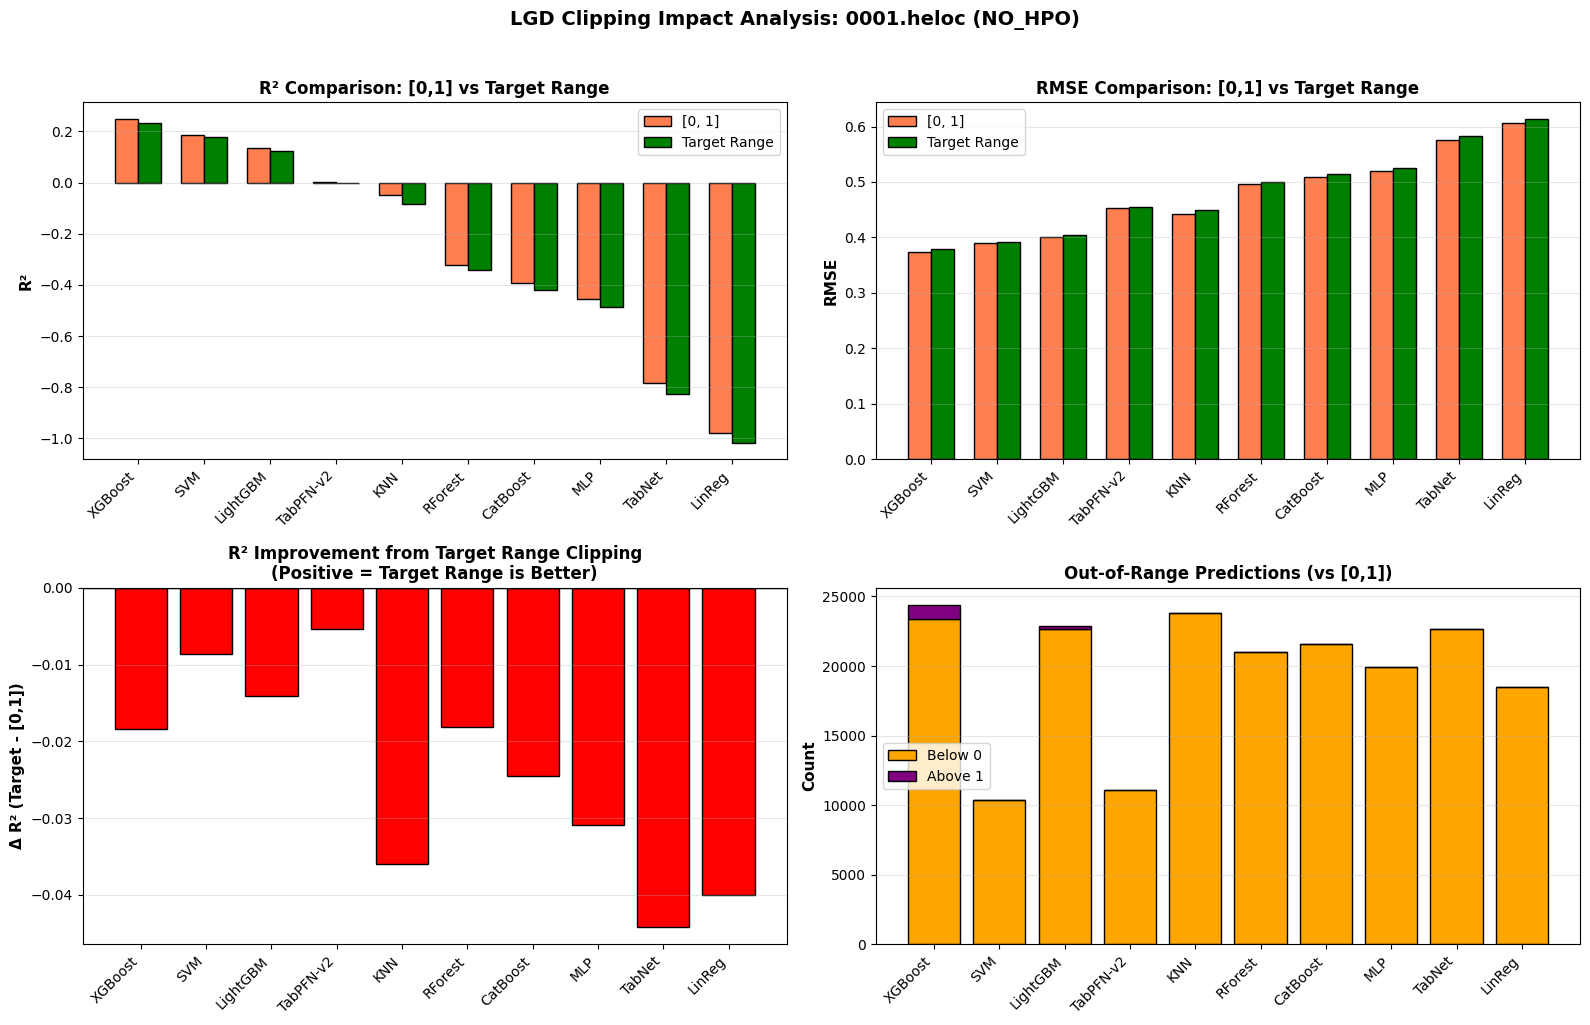


📊 Best improvement:  TabPFN-v2 (Δ R² = -0.0054)
📊 Worst improvement: TabNet (Δ R² = -0.0443)

Analyzing: 0002.loss2
LGD CLIPPING IMPACT: ALL METHODS COMPARISON
Loading: C:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results\experiment1\lgd\0002.loss2.pkl

Dataset: 0002.loss2
HPO Mode: NO_HPO
Methods: 10

📊 CLIPPING IMPACT SUMMARY:
----------------------------------------------------------------------------------------------------
Method                    R²[0,1]   R²[target]       Δ R²    RMSE[0,1] RMSE[target]     Δ RMSE
----------------------------------------------------------------------------------------------------
LinReg                     0.4333       0.4333    +0.0000       0.2043       0.2043    +0.0000
TabPFN-v2                  0.3473       0.3473    +0.0000       0.2192       0.2192    +0.0000
LightGBM                   0.3462       0.3462    +0.0000       0.2194       0.2194    +0.0000
RForest                    0.3456       0.3456

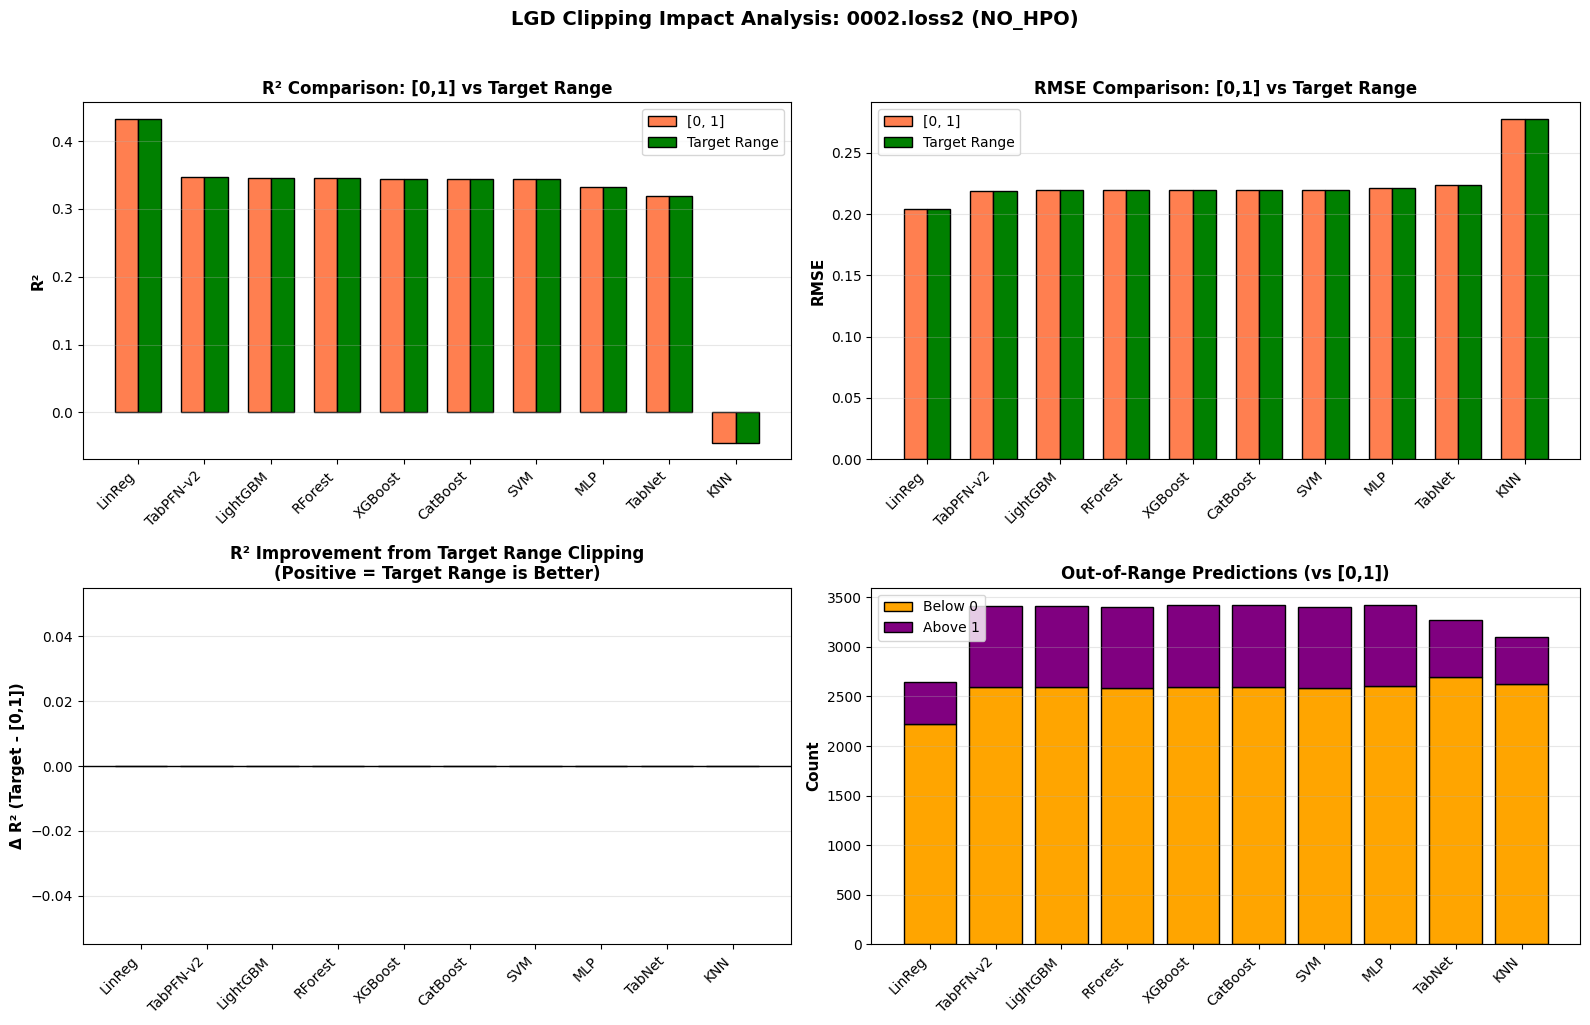


📊 Best improvement:  LinReg (Δ R² = +0.0000)
📊 Worst improvement: LinReg (Δ R² = +0.0000)

Analyzing: 0003.axa
LGD CLIPPING IMPACT: ALL METHODS COMPARISON
Loading: C:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results\experiment1\lgd\0003.axa.pkl

Dataset: 0003.axa
HPO Mode: NO_HPO
Methods: 10

📊 CLIPPING IMPACT SUMMARY:
----------------------------------------------------------------------------------------------------
Method                    R²[0,1]   R²[target]       Δ R²    RMSE[0,1] RMSE[target]     Δ RMSE
----------------------------------------------------------------------------------------------------
LinReg                     0.0700       0.0700    +0.0000       0.3173       0.3173    +0.0000
MLP                       -0.0373      -0.0373    +0.0000       0.3351       0.3351    +0.0000
CatBoost                  -0.0459      -0.0458    +0.0000       0.3365       0.3365    +0.0000
TabNet                    -0.0622      -0.0622    +0.00

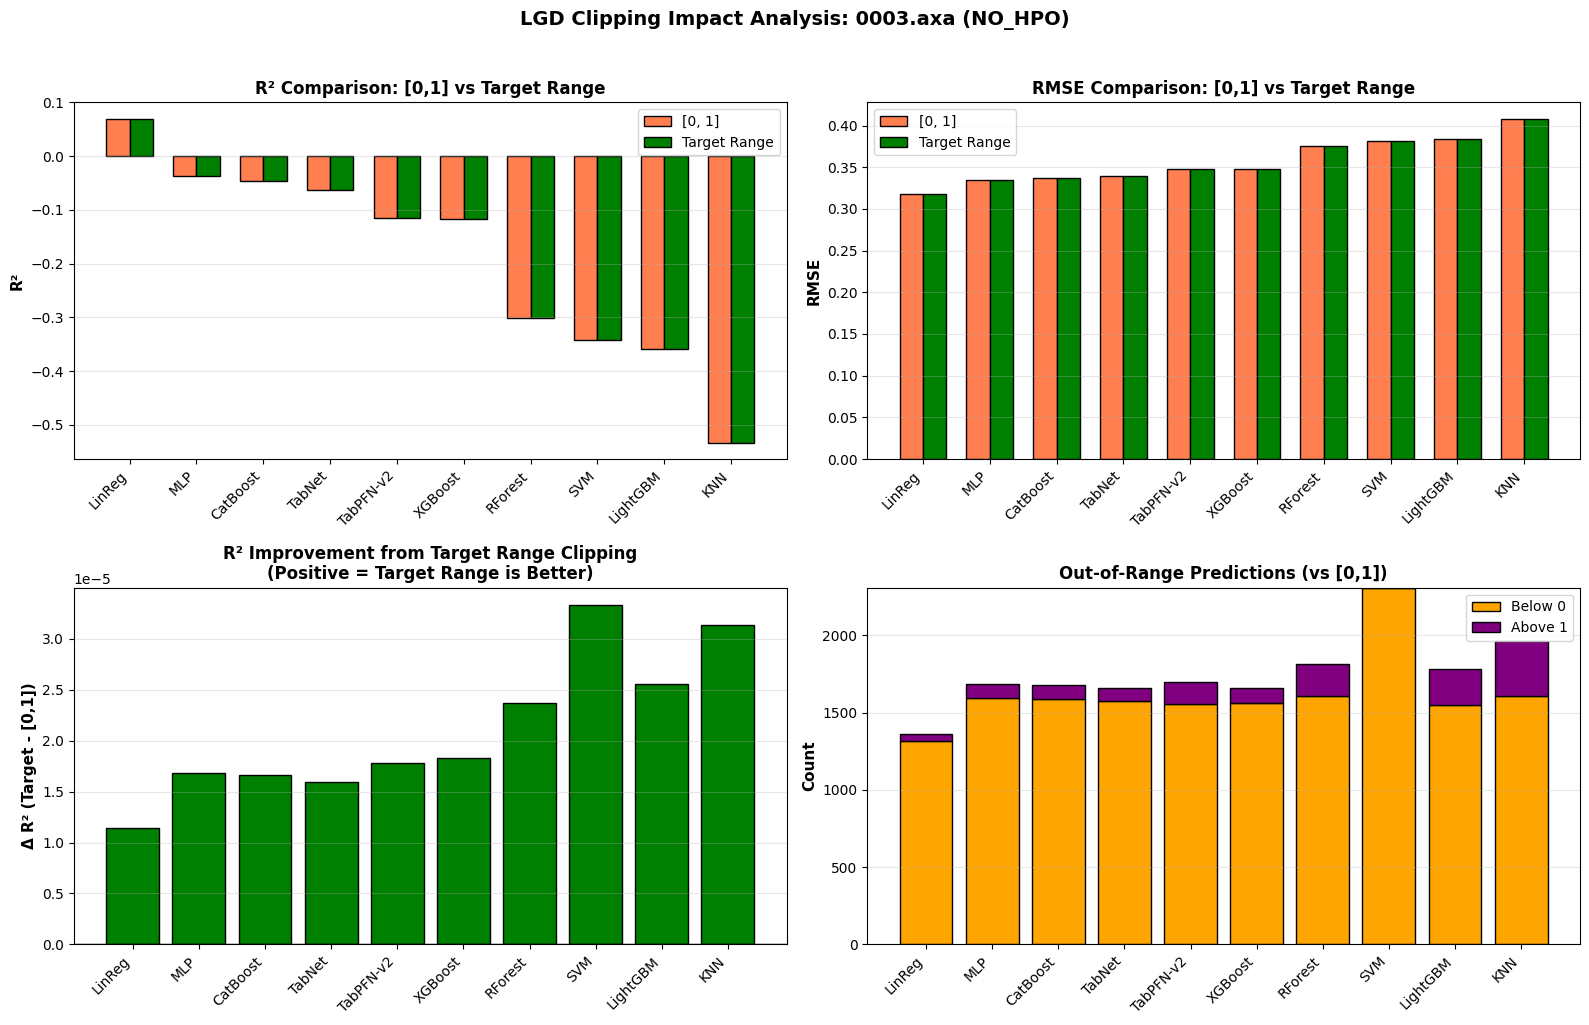


📊 Best improvement:  SVM (Δ R² = +0.0000)
📊 Worst improvement: LinReg (Δ R² = +0.0000)

Analyzing: 0004.base_model
LGD CLIPPING IMPACT: ALL METHODS COMPARISON
Loading: C:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results\experiment1\lgd\0004.base_model.pkl

Dataset: 0004.base_model
HPO Mode: NO_HPO
Methods: 10

📊 CLIPPING IMPACT SUMMARY:
----------------------------------------------------------------------------------------------------
Method                    R²[0,1]   R²[target]       Δ R²    RMSE[0,1] RMSE[target]     Δ RMSE
----------------------------------------------------------------------------------------------------
CatBoost                  -0.2004      -0.2004    +0.0000       0.4135       0.4135    +0.0000
XGBoost                   -0.2291      -0.2291    +0.0000       0.4184       0.4184    +0.0000
RForest                   -0.2384      -0.2384    +0.0000       0.4200       0.4200    +0.0000
KNN                       -0.2590    

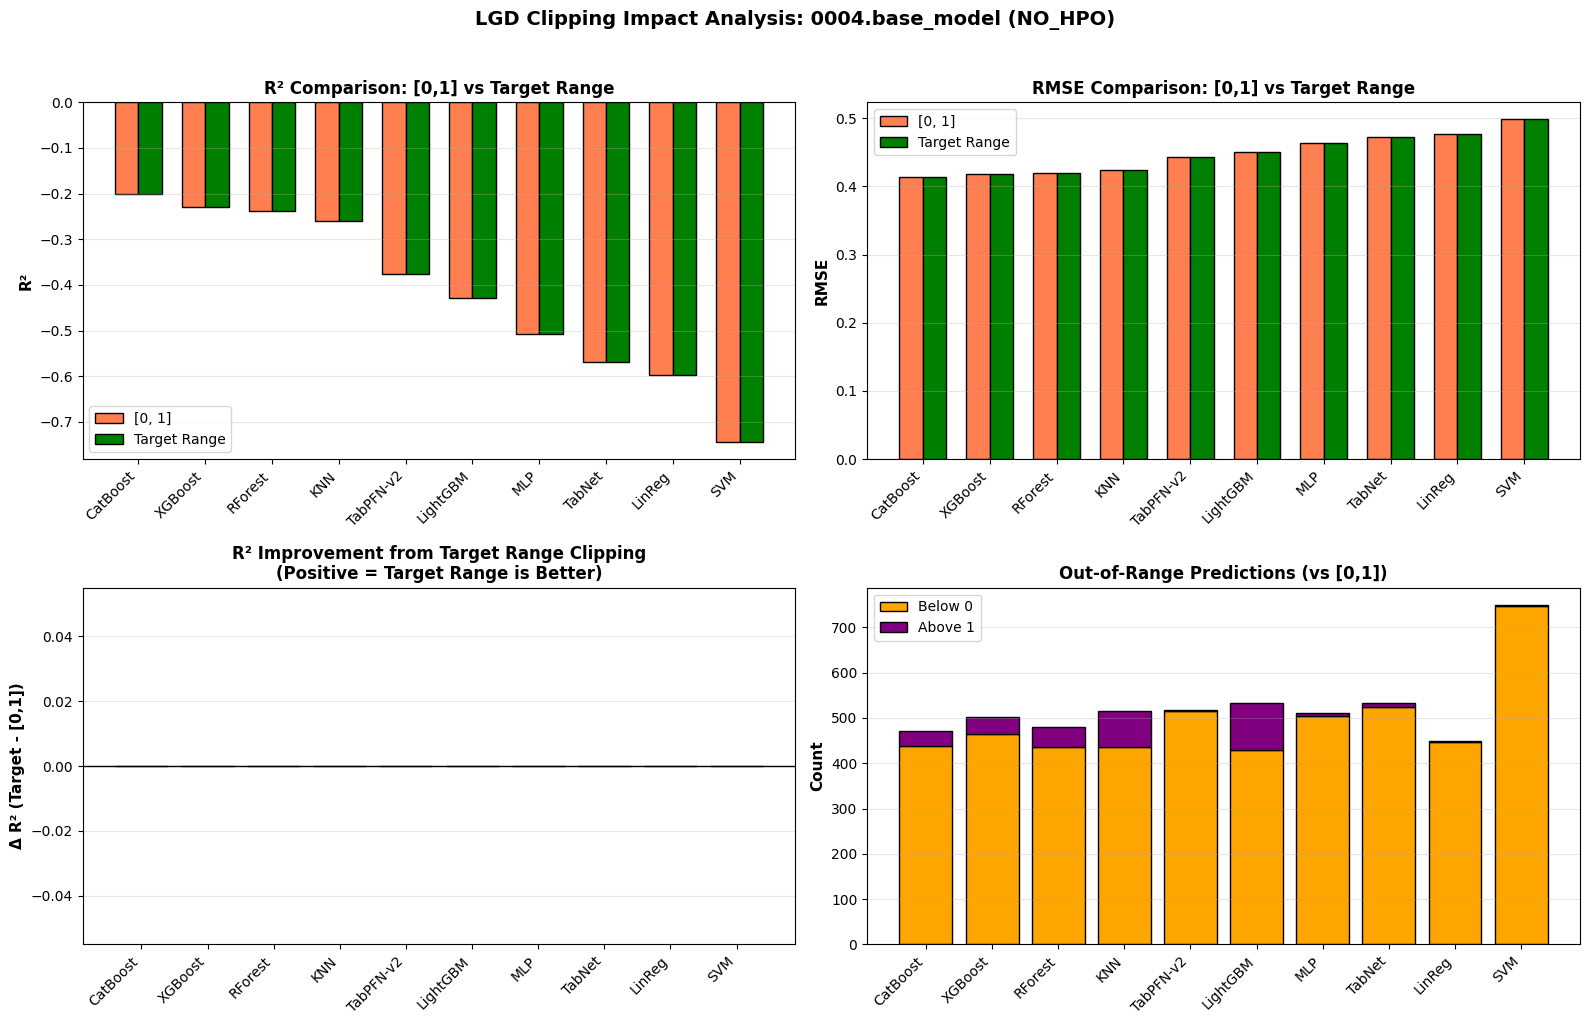


📊 Best improvement:  CatBoost (Δ R² = +0.0000)
📊 Worst improvement: CatBoost (Δ R² = +0.0000)

Analyzing: 0005.base_modelisation
LGD CLIPPING IMPACT: ALL METHODS COMPARISON
Loading: C:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results\experiment1\lgd\0005.base_modelisation.pkl

Dataset: 0005.base_modelisation
HPO Mode: NO_HPO
Methods: 10

📊 CLIPPING IMPACT SUMMARY:
----------------------------------------------------------------------------------------------------
Method                    R²[0,1]   R²[target]       Δ R²    RMSE[0,1] RMSE[target]     Δ RMSE
----------------------------------------------------------------------------------------------------
TabPFN-v2                  0.5084       0.5084    +0.0000       0.2870       0.2870    +0.0000
CatBoost                   0.3273       0.3273    +0.0000       0.3358       0.3358    +0.0000
RForest                    0.2962       0.2962    +0.0000       0.3435       0.3435    +0.0000
XGBoost  

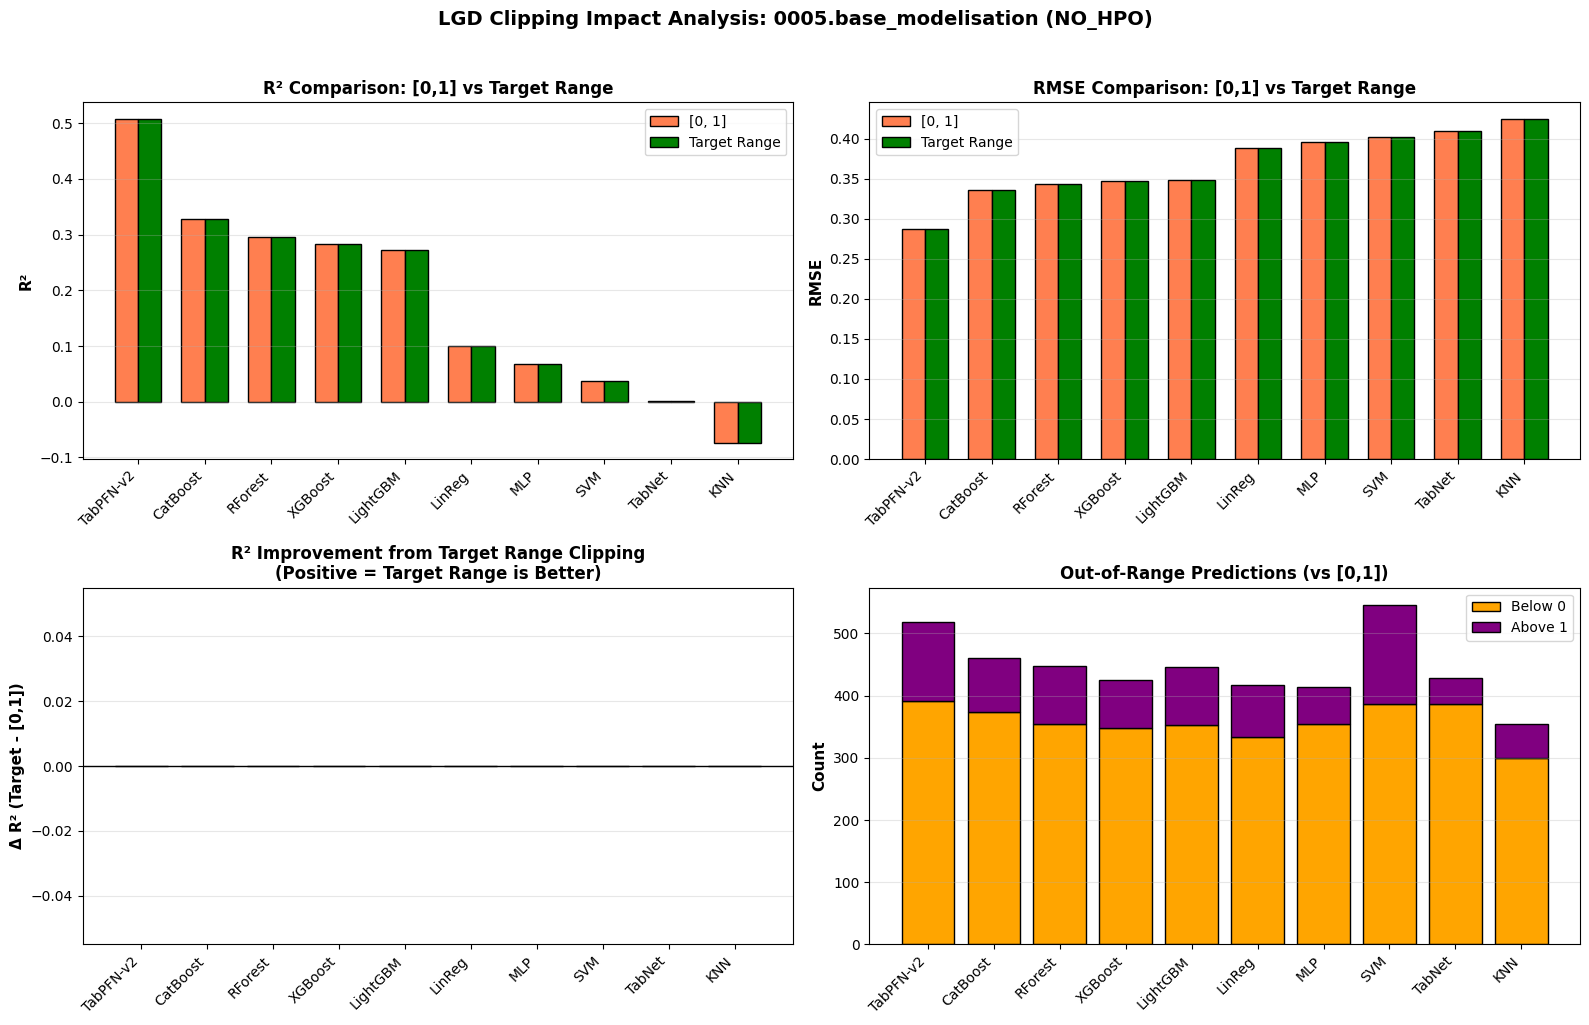


📊 Best improvement:  TabPFN-v2 (Δ R² = +0.0000)
📊 Worst improvement: TabPFN-v2 (Δ R² = +0.0000)


In [5]:
# =============================================================================
# LGD CLIPPING IMPACT: ALL METHODS COMPARISON
# =============================================================================

lgd_datasets = list_lgd_datasets(LGD_RESULTS_DIR)

if lgd_datasets:
    for dataset in lgd_datasets:
        print(f"\n{'='*80}")
        print(f"Analyzing: {dataset}")
        print(f"{'='*80}")
        
        comparison = compare_all_methods_clipping(
            results_dir=LGD_RESULTS_DIR,
            dataset=dataset,
            hpo_mode='NO_HPO',  # or 'HPO'
            figsize=(16, 10)
        )
        
        if comparison is not None:
            best_improvement = comparison.loc[comparison['R2_improvement'].idxmax()]
            worst_improvement = comparison.loc[comparison['R2_improvement'].idxmin()]
            
            print(f"\n📊 Best improvement:  {best_improvement['display_name']} (Δ R² = {best_improvement['R2_improvement']:+.4f})")
            print(f"📊 Worst improvement: {worst_improvement['display_name']} (Δ R² = {worst_improvement['R2_improvement']:+.4f})")
else:
    print("❌ No LGD datasets found")